In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import r2_score,accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB,BernoulliNB
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [8]:
df = pd.get_dummies(df)

In [9]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [10]:
df = df.astype(int)

<Axes: xlabel='Cholesterol', ylabel='Count'>

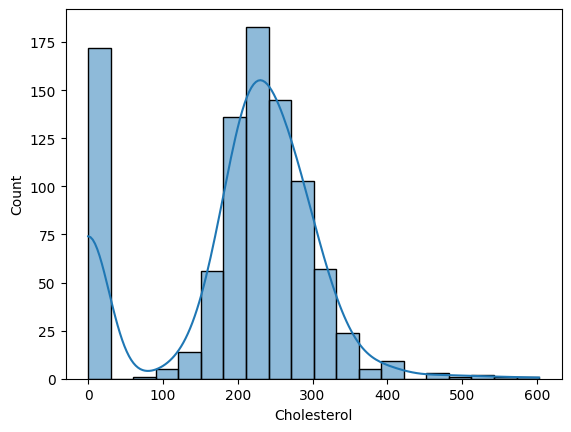

In [11]:
sns.histplot(x = 'Cholesterol',kde=True,bins=20,data=df)

<Axes: xlabel='Age', ylabel='Count'>

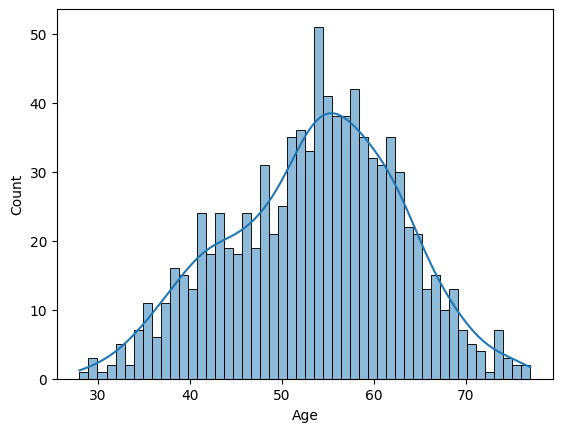

In [12]:
sns.histplot(x='Age',data=df,kde=True,bins=50)

In [13]:
ch_mean = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [14]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)

<Axes: xlabel='RestingBP', ylabel='Count'>

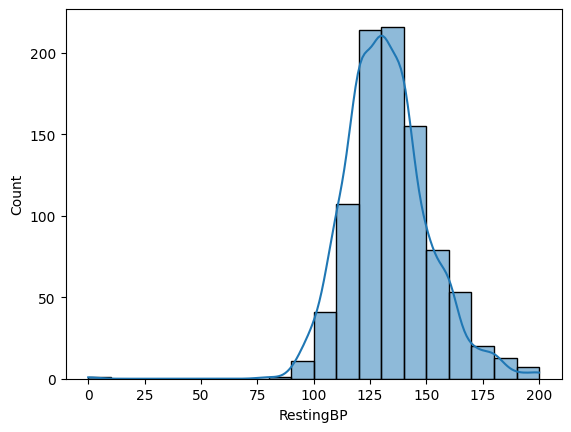

In [15]:
sns.histplot(x='RestingBP',data=df,bins=20,kde=True)

In [16]:
BP_mean = df.loc[df['RestingBP']!=0,'RestingBP'].mean()

In [17]:
df['RestingBP'] = df['RestingBP'].replace(0,BP_mean)

In [18]:
numeric_col = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df[numeric_col] = scaler.fit_transform(df[numeric_col])

In [19]:
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.727592,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212922,0,0.754157,0.282891,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.727592,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.282891,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.727592,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253656,0.363389,0,-0.188999,0.282891,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,1.536902,0.637320,-0.968969,1,0.164684,2.303858,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,0.370100,-0.141317,-2.132437,0,-0.857069,0.282891,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,0.370100,-0.141317,-0.162048,0,1.461525,-0.727592,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [20]:
X = df.drop(['HeartDisease'],axis=1)
y = df['HeartDisease']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(),
    'KNN' : KNeighborsClassifier(),
    'Naive Bayes' : GaussianNB(),
    'Decision Tree' : DecisionTreeClassifier(),
    'svm' : SVC()    
}

In [ ]:
result = []

In [ ]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'model' : name,
        'accuracy' : round(acc,4),
        'F1 score' : round(f1,4)
    })

In [ ]:
result

[{'model': 'Logistic Regression', 'accuracy': 0.8641, 'F1 score': 0.8792},
 {'model': 'KNN', 'accuracy': 0.8587, 'F1 score': 0.875},
 {'model': 'Naive Bayes', 'accuracy': 0.8424, 'F1 score': 0.8557},
 {'model': 'Decision Tree', 'accuracy': 0.8152, 'F1 score': 0.8247},
 {'model': 'svm', 'accuracy': 0.8478, 'F1 score': 0.8679}]

In [ ]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']